---
title: "Лабораторна робота 2. Побудова лінійного бінарного класифікатора на основі оптимізації функціонала якості"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "12.03.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: реалізузвати бінарний класифікатор на основі оптимізації функціонала якості засобами мови Python

## Завдання для самостійної роботи 

1. Імпортувати дані для навчальної вибірки згідно з індивідуальним варіантом (імпорт організувати з файлу).
1. Побудувати бінарний МНК-класифікатор згідно з розглянутим вище прикладом і вивести результати бінарної класифікації на графіку.
1. Проаналізувати  отримані результати і порівняти їх з результатами, отриманими у лаб роб. 1.
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_2_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

 Варіант 2:
 x_train_2:
 [[17 29]
  [44 12]
  [47  7]
  [18 17]
  [30 36]
  [ 6 10]
  [38  6]
  [10 38]
  [41 10]
  [42 10]];
 y_train_2:
 [ 1  1  1 -1  1  1 -1 -1  1 -1]

[ 0.04942445 -0.03055687 -0.9133912 ]


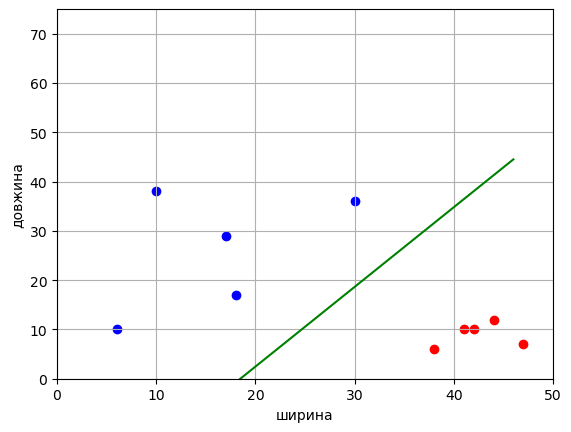

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [1] for x in x_train]  # Додаємо зміщення для кожного прикладу
x_train = np.array(x_train)
y_train = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

pt = np.sum([x * y for x, y in zip(x_train, y_train)], axis=0)  # Обчислення підсумку
xxt = np.sum([np.outer(x, x) for x in x_train], axis=0)  # Обчислення підсумку зовнішнього добутку
w = np.dot(pt, np.linalg.inv(xxt))  # Обчислення вагових коефіцієнтів
print(w)

line_x = list(range(max(x_train[:, 0])))    # формування координат для лінії розділення
line_y = [-x*w[0]/w[1] - w[2]/w[1] for x in line_x]

x_0 = x_train[y_train == 1]                 # формування точок для класу 1
x_1 = x_train[y_train == -1]                # і класу -1

plt.scatter(x_0[:, 0], x_0[:, 1], color='red')  # відображення точок класу 1 червоним кольором
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')  # відображення точок класу -1 синім кольором
plt.plot(line_x, line_y, color='green')  # відображення лінії розділення зеленим кольором

plt.xlim([0, 50])
plt.ylim([0, 75])
plt.ylabel("довжина")
plt.xlabel("ширина")
plt.grid(True)
plt.show()